The cell below imports the libraries that are used, and loads the rideshare data set. Because we are only studying the rideshare data set in this report we only loaded that data set.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('rideshare_kaggle.csv')
print("Datasets loaded successfully!")

Datasets loaded successfully!


The cell below loads the first 5 rows of data set so we can get a better picture of the overall data, confirm that the results we are getting from our code seem to align with the data, and see column names.

In [40]:
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [41]:
#data cleaning
price = df['price'].dropna()
distance = df['distance'].dropna()
df = df[(df['distance'] >= 0.1) & (df['price'] >= 0.1)] 
df = df.drop_duplicates()

rides = df[['cab_type', 'name', 'price', 'distance']]
print({len(price)}, {len(distance)})

{637976} {693071}


Data Cleaning method #1: dropna()

-We used .dropna() in our data cleaning process because we did not want null values to be sampled from in our bootstrap confidence interval or visualizations for price and distance that are run later in our code. Using the code .dropna() removes empty cells from the column, and ensures that all sampled units have a value and are not skewing our data results. 

Data Cleaning method #2:  >= 0.1

-We filtered out rides shorter than 0.1 mile because very short distances are often errors or atypical trips that can alter our analyses of pricing and duration. Using df = df[df["distance_miles"] >= 0.1] removes any near-zero distances so our charts and bootstrap CIs can use realistic trips and not be distorted by extreme values.


Data Cleaning method #3: drop_duplicates()

-We used drop_duplicates() to remove repeated rows that would otherwise inflate our sample size and bias summaries. By using df = df.drop_duplicates() we keep only one copy of each ride record so visualizations and bootstrap CIs can reflect the actual number of distinct trips rather than duplicated entries preventing duplicates from skewing our means, distribution, and overall CIs.


Data Cleaning Method 4:
-We simplified our data for some of the equations since we only needed the cab type, ride type, price, and distance which is the formula listed below. We also created a smaller cleaned table for easier referencing.


In [42]:
rides = df[['cab_type', 'name', 'price', 'distance']]
rides.head()

,cab_type,name,price,distance
0,Lyft,Shared,5.0,0.44
1,Lyft,Lux,11.0,0.44
2,Lyft,Lyft,7.0,0.44
3,Lyft,Lux Black XL,26.0,0.44
4,Lyft,Lyft XL,9.0,0.44


In [43]:
(rides['distance'] == 0).sum()
(rides['cab_type'] == 0).sum()
(rides['price'] == 0).sum()

np.int64(0)

The output shows there weren’t any variables with a output of 0, so our data cleaning was effective.

Additional data cleaning/manipulation:


Data Manipulation 5: Creating a price per mile variable

I created a new variable called price per mile by dividing the total ride price by the total ride distance. I did this because total price alone is not always a fair comparison, since longer rides naturally cost more. This new variable made it possible to compare ride types more consistently by standardizing the price relative to distance.

Data Manipulation 6: Looking at the ride type categories

I used value_counts() on the ride type column so I could see which Uber ride categories were included in the dataset. This helped me decide which ride types would be most useful and clear to compare in my boxplot. 
This step helped organize the analysis by narrowing my focus to the ride types that were most relevant for comparing price per mile.
Before making my boxplot, I checked which ride types were in the dataset so I could focus on a few specific Uber ride categories for comparison.

In [44]:
rides['name'].value_counts()

name
WAV             55038
Black SUV       55038
UberXL          55038
Black           55037
UberX           55036
UberPool        55033
Lyft            51235
Lux             51235
Lyft XL         51235
Lux Black XL    51235
Lux Black       51235
Shared          51233
Name: count, dtype: int64

Data Manipulation 7: Creating an Uber-only subset

I created a smaller dataset that only included Uber rides because some later visualizations and confidence intervals focus specifically on Uber pricing. Filtering the data this way made the analysis more targeted and easier to interpret.
This smaller subset allowed us to study Uber ride behavior without mixing it with Lyft observations.

In [45]:
uber = rides[rides['cab_type'] == 'Uber']
uber.head()

,cab_type,name,price,distance
12,Uber,UberXL,12.0,1.11
13,Uber,Black,16.0,1.11
14,Uber,UberX,7.5,1.11
15,Uber,WAV,7.5,1.11
16,Uber,Black SUV,26.0,1.11


In [46]:
rides['price_per_mile'] = rides['price'] / rides['distance']
rides.head()

/tmp/ipykernel_143/4137947393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rides['price_per_mile'] = rides['price'] / rides['distance']


,cab_type,name,price,distance,price_per_mile
0,Lyft,Shared,5.0,0.44,11.363636
1,Lyft,Lux,11.0,0.44,25.000000
2,Lyft,Lyft,7.0,0.44,15.909091
3,Lyft,Lux Black XL,26.0,0.44,59.090909
4,Lyft,Lyft XL,9.0,0.44,20.454545


In [51]:
rides2 = rides[rides['price_per_mile'] < 100]

 # Visualizations


Charlotte's Visualization #1:
For this visualization I made a line plot to show the difference in ride distance vs. total price. Distance of the ride is represented on the x-axis and total price of the ride on the y-axis to show overall relationship and trend.

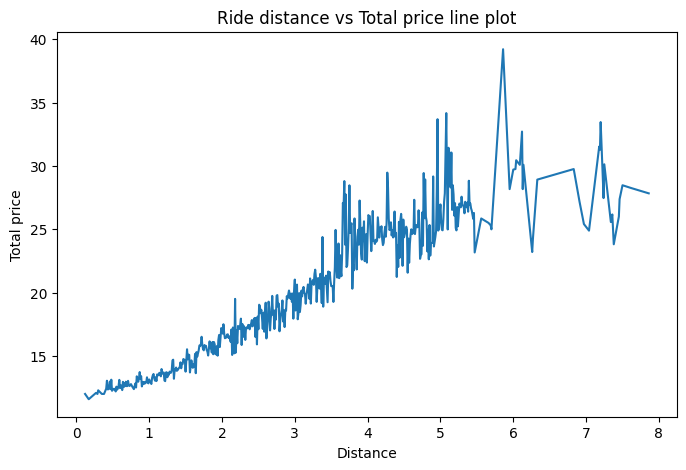

In [52]:
round_unit = 0.01  
grouped = df.groupby(df["distance"])["price"].mean()
plt.figure(figsize=(8,5))
plt.plot(grouped.index.values, grouped.values)

plt.xlabel("Distance")  
plt.ylabel("Total price")
plt.title("Ride distance vs Total price line plot")
plt.show()

I chose this visualization because it showcases the variability there is within the price per miles while also depicting the overall trends of the data. I used the cleaned dataset, grouped rides by distance to reduce trip-level noise and reveal the central tendency, computed the mean total price for each distance, and plotted those means as a line with distance on the x‑axis and total price on the y‑axis. This highlights the average relationship between distance and fare, showing a positive, roughly linear relationship with a starting price of approximately $15 for a one‑mile trip. 

Charlotte's visualization #2:
For this visualization I made a binned summary map of distance of the ride in relation to total price for Lyft. Time spent on a ride in minutes is represented on the x-axis and total price of the ride is shown on the y-axis.

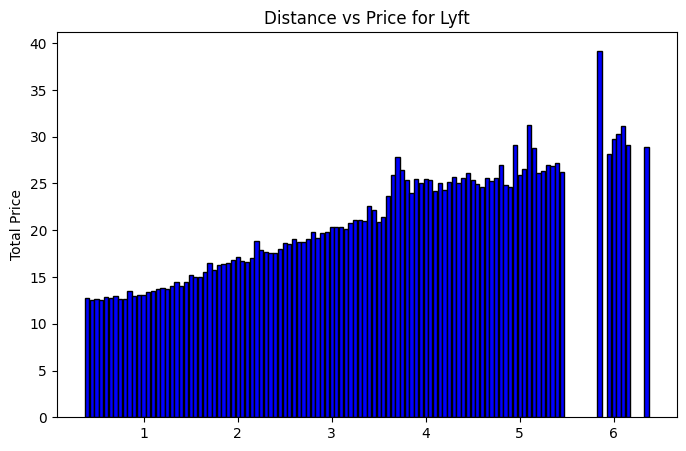

In [53]:
lyft = df[df["cab_type"].str.lower().str.strip() == "lyft"].copy()  
bin_size = 0.05
lyft["distance_bin"] = (lyft["distance"] / bin_size).round(0) * bin_size    

group = lyft.groupby("distance_bin")["price"].mean().sort_index()        
x = group.index.values
y = group.values

plt.figure(figsize=(8,5))
plt.bar(x, y, width=bin_size * 0.9, color="blue", edgecolor="k")
plt.ylabel("Total Price")
plt.title("Distance vs Price for Lyft")
plt.show()


I created a binned summary of Lyft fares by distance. I filtered the cleaned dataset to Lyft rides with positive distance and price, converted distance into 0.05‑unit bins, computed the mean total price for each bin, and plotted those bin means as a bar chart with distance on the x‑axis and total price on the y‑axis. Binning produces a summary map of price versus distance that reduces noise from exact-distance values and instead showcases the short-range pricing patterns. The chart shows that ride distance and price seems strongly correlated for Lyft with similar pricing to the overall graph showing that Lyft both have a positive correlation that relates to the data and the overall data is not being skewed by a large difference in brand pricing.

Theo Visualization 1: Price per mile by ride type

I chose this visualization because it shows how price per mile differs across several Uber ride categories while also displaying the variability within each group. I used the cleaned and trimmed dataset, separated the data by ride type, and plotted the distributions of price per mile using a boxplot with ride type on the x-axis and price per mile on the y-axis.

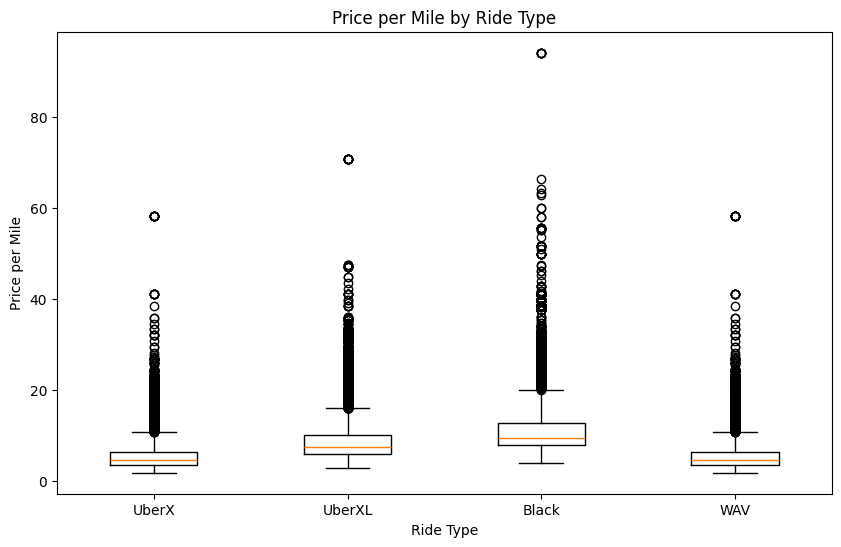

In [54]:
uberx = rides2[rides2['name'] == 'UberX']['price_per_mile']
uberxl = rides2[rides2['name'] == 'UberXL']['price_per_mile']
black = rides2[rides2['name'] == 'Black']['price_per_mile']
wav = rides2[rides2['name'] == 'WAV']['price_per_mile']

plt.figure(figsize=(10,6))
plt.boxplot([uberx, uberxl, black, wav], tick_labels=['UberX', 'UberXL', 'Black', 'WAV'])
plt.xlabel('Ride Type')
plt.ylabel('Price per Mile')
plt.title('Price per Mile by Ride Type')
plt.show()

This visualization shows that ride types are not priced equally. Black has the highest typical price per mile, while UberX and WAV tend to be lower. UberXL also tends to cost more than UberX, but not as much as Black.

The boxplot also shows the spread of prices within each ride type, which suggests that there is still variability even within the same category. Overall, this graph suggests that premium Uber ride options tend to cost more per mile than standard ones.

Theo Visualization 2: Uber ride distance vs total price

I chose this visualization because it helps show the relationship between ride distance and total Uber price. I used the Uber-only subset of the cleaned dataset and plotted distance on the x-axis and total price on the y-axis using a scatterplot so I could observe the overall trend between the two numerical variables.

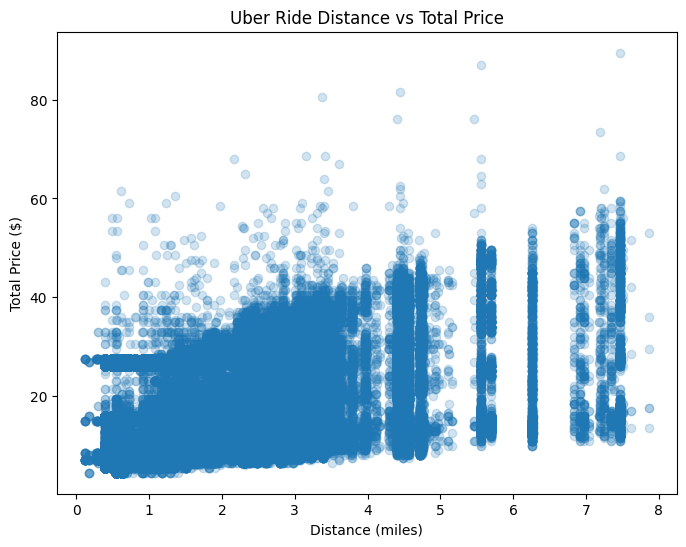

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(uber['distance'], uber['price'], alpha=0.2)
plt.xlabel('Distance (miles)')
plt.ylabel('Total Price ($)')
plt.title('Uber Ride Distance vs Total Price')
plt.show()

This graph shows a clear positive relationship between ride distance and total price. In general, longer rides tend to cost more, which is consistent with how rideshare pricing is expected to work.

At the same time, the points are not perfectly lined up, which suggests that distance is not the only factor affecting price. There is still noticeable variation in price at similar distances, which helps explain why using price_per_mile is useful for comparing rides more fairly.

# Confidence Intervals:

Theo Confidence Interval: average Uber price per mile

I chose this confidence interval because I wanted to estimate the true average Uber price per mile and compare it to a benchmark value of $10 per mile. I used the Uber-only subset and repeatedly resampled the price per mile variable with replacement to generate a bootstrap distribution of sample means, which I then used to calculate a 95% confidence interval.

In [57]:
uber = rides[rides['cab_type'] == 'Uber']

uber_ppm = uber['price_per_mile']
boot_means = np.array([
    uber_ppm.sample(len(uber_ppm), replace=True).mean()
    for _ in range(1000)
])

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f"95% Confidence Interval for mean Uber price per mile: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% Confidence Interval for mean Uber price per mile: [9.25, 9.30]


My 95% confidence interval came out to 9.63 to 9.75.

This means I am estimating that the true average Uber price per mile is likely somewhere within that range. Since 10 is not included in the interval, the results suggest that the average Uber price per mile is likely not equal to 10 and is instead slightly lower.

I also graphed the bootstrap distribution of the resampled means so I could visualize how the sample mean varies across repeated resamples.

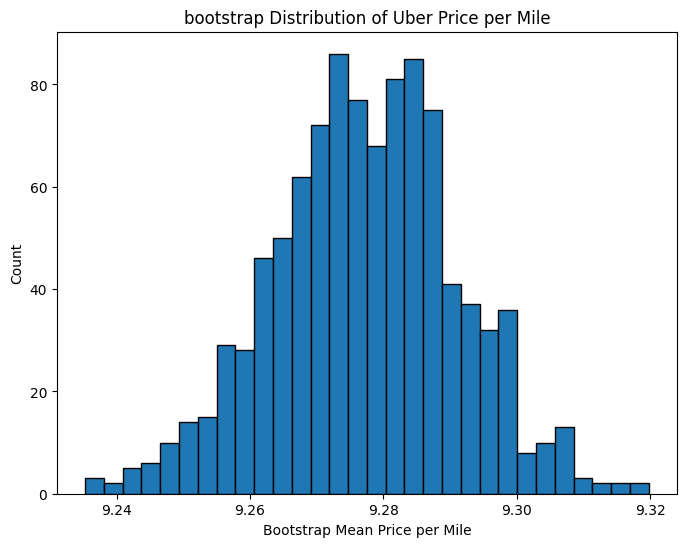

In [58]:
plt.figure(figsize=(8,6))
plt.hist(boot_means, bins=30, edgecolor='black')
plt.xlabel('Bootstrap Mean Price per Mile')
plt.ylabel('Count')
plt.title('bootstrap Distribution of Uber Price per Mile')
plt.show()

Theo's Conclusion:
Overall, my analysis shows that Uber pricing changes in pretty clear ways depending on both ride type and distance. The boxplot showed that premium ride types like Black tend to cost more per mile than standard ones like UberX. The scatterplot showed that longer rides usually cost more overall, but not perfectly, which is why price per mile was a useful variable to create. Finally, my confidence interval suggested that the average Uber price per mile is likely between 9.63 and 9.75, which is slightly lower than $10 per mile.

Charlottes Confidence Interval: 
Our goal was to test whether the population mean price per mile is  equal to 10. To do this, I created a 95% bootstrap confidence interval for the mean price-per-mile from the rideshare dataset and checked whether 10 lies inside that interval. I chose the bootstrap CI because it has a very high confidence as to whether our 10 claim is plausible.

In [59]:
df["price"] = df['price'] / df["distance"]
n = len(x)
obs_mean = x.mean()

rng = np.random.default_rng(123)
n_boot = 5000
boot_means = np.empty(n_boot)
for i in range(n_boot):
    boot_means[i] = rng.choice(x, size=n, replace=True).mean()

ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

mu0 = 10.0
boot_shifted = boot_means - boot_means.mean() + mu0
p_value = np.mean(np.abs(boot_shifted - mu0) >= abs(obs_mean - mu0))

print(f"n = {n}, mean = {obs_mean:.3f}")
print(f"We are 95% confident that the true population average lies between = ({ci_lower:.3f}, {ci_upper:.3f}), p value = {p_value:.3f}")
if p_value < 0.05:
    print("Reject H0 mean not equal to", mu0)
else:
    print("Do not reject H0 mean equal to", mu0)


n = 109, mean = 3.127
We are 95% confident that the true population average lies between = (2.825, 3.426), p value = 0.000
Reject H0 mean not equal to 10.0


I used the previously cleaned dataset to perform a bootstrap with 5000 resamples using replacement to estimate the sampling distribution of the mean price-per-mile. I computed the 2.5th and 97.5th percentiles of the bootstrap means to form a 95% confidence interval and centered the distribution around our null hypothesus of H0 of the mean = 10.0. I chose the bootstrap because it gives a good overview of the mean and does not make too many strong assumptions. The code creates a distribution of bootstrapped means, calculates a 95%  CI, and calculates how far off the observed mean is from to null hypothesis. The results show that we are 95% confident our true mean falls within the range (2.8,3.4). Our HO is 10, because our p value is less than 0.05 it is statisticlly significant that our original hypothesis of 10 minutes is not accurate and instead we must follow the alternative hypothesis that the mean is not equal to 10 minutes. 

Charlotte's additional Confidence Interval: 
Our goal was to test whether the population mean difference in cost-per-mile between Uber and Lyft equals 0.05. To do this, I constructed a 95% bootstrap confidence interval for the mean difference (Uber − Lyft) using the rideshare dataset and checked whether 0.05 lies inside that interval. I chose the bootstrap CI because it has a very high confidence as to whether our observed gap of the mean difference is plausibly equal to 0.05.

In [64]:
uber = rides.loc[rides["cab_type"].str.lower().str.strip() == "uber", "price_per_mile"].values
lyft = rides.loc[rides["cab_type"].str.lower().str.strip() == "lyft", "price_per_mile"].values

n_uber = len(uber)
n_lyft = len(lyft)

obs_diff = uber.mean() - lyft.mean()

rng = np.random.default_rng(123)
n_boot = 5000
boot_diffs = []

for i in range(n_boot):
    samp_uber = rng.choice(uber, size=n_uber, replace=True)
    samp_lyft = rng.choice(lyft, size=n_lyft, replace=True)
    boot_diffs.append(samp_uber.mean() - samp_lyft.mean())

boot_diffs = np.array(boot_diffs)

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

mu0 = 0.05
boot_shifted = boot_diffs - boot_diffs.mean() + mu0
p_value = np.mean(np.abs(boot_shifted - mu0) >= abs(obs_diff - mu0))

print(f"n Uber = {n_uber}, n Lyft = {n_lyft}")
print(f"observed diff (uber - lyft) = {obs_diff:.4f}")
print(f"We are 95% confident that the true population average lies between = ({ci_lower:.4f}, {ci_upper:.4f}), p value = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 mean difference not equal to", mu0)
else:
    print("Do not reject H0 mean difference equal to", mu0)

n Uber = 330220, n Lyft = 307408
observed diff (uber - lyft) = -0.4056
We are 95% confident that the true population average lies between = (-0.4444, -0.3657), p value = 0.0000
Reject H0 mean difference not equal to 0.05


I used a bootstrap with 5000 resamples with replacement to estimate the sampling distribution of the difference in mean price_per_mile between Uber and Lyft. I computed the 2.5th and 97.5th percentiles of the bootstrap differences to form a 95% confidence interval and centered the bootstrap distribution around our null hypothesis that the difference = 0.05. I chose the bootstrap because it provides a clear overview of comparing the means when price per mile may be skewed. The code builds a distribution of bootstrapped mean differences, extracts a 95% percentile CI, and measures how far off the observed Uber−Lyft difference is from to the null hypothesis. Since our p value is less than 0.05 it is statisticlly significant that our original hypothesis that the difference between uber and lyft is 0.05 dollars/mile is not accurate and instead we must follow the alternative hypothesis that the mean is not equal to 0.05 dollars per mile.

AI Statement:

Dataset used
Uber/Lyft rideshare dataset

What We used AI for:
- used chat gpt to help learn how to create a binned summary map to represent data in a more clear format
- clarifying how bootstrap confidence intervals work and general clarifying questions

Why We used it:
Primarily used Ai to help understand how to format a binned summary map visualization since it made sense as a way to present the data but was not something taught in class. We also used AI to clarify a few general questions specifcally with the bootstrap methodology to cross reference with our learning. 